In [34]:
import warnings
warnings.filterwarnings("ignore")

import psycopg2
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.15)
plt.rcParams.update({"figure.dpi": 130, "axes.spines.top": False, "axes.spines.right": False})

conn = psycopg2.connect(
    host="127.0.0.1", port=5455, dbname="postgres",
    user="postgres", password="postgres"
)
print("Connected ✓")

Connected ✓


In [35]:
cur = conn.cursor()
cur.execute("""
    SELECT table_schema, table_name, column_name, data_type
    FROM information_schema.columns
    WHERE table_schema IN ('int', 'raw', 'stg')
    ORDER BY table_schema, table_name, ordinal_position
""")
for row in cur.fetchall():
    print(row)

('int', 'int_game_environment', 'game_id', 'bigint')
('int', 'int_game_environment', 'season', 'integer')
('int', 'int_game_environment', 'week', 'integer')
('int', 'int_game_environment', 'home_team', 'text')
('int', 'int_game_environment', 'away_team', 'text')
('int', 'int_game_environment', 'venue_id', 'bigint')
('int', 'int_game_environment', 'is_dome', 'boolean')
('int', 'int_game_environment', 'venue_elevation_ft', 'double precision')
('int', 'int_game_environment', 'away_home_elevation_ft', 'double precision')
('int', 'int_game_environment', 'away_elevation_delta_ft', 'double precision')
('int', 'int_game_environment', 'away_elevation_ascent_ft', 'double precision')
('int', 'int_game_environment', 'away_travel_distance_mi', 'numeric')
('int', 'int_game_environment', 'away_tz_delta_hrs', 'integer')
('int', 'int_game_environment', 'temperature_f', 'numeric')
('int', 'int_game_environment', 'wind_speed_mph', 'numeric')
('int', 'int_game_environment', 'wind_gusts_mph', 'numeric')
('

In [36]:
cur.execute("""
    SELECT
        f.game_id,
        f.team_name,
        f.season,
        f.points_scored - f.points_allowed          AS point_differential,
        f.points_scored,
        f.points_allowed,
        f.off_epa_per_play,
        f.def_epa_per_play_allowed,
        e.home_team,
        e.away_team,
        e.venue_elevation_ft,
        e.away_home_elevation_ft,
        e.away_elevation_delta_ft,
        e.away_travel_distance_mi,
        e.away_tz_delta_hrs,
        e.temperature_f,
        e.wind_speed_mph,
        e.humidity_pct,
        e.precipitation_inches,
        e.is_dome,
        e.is_high_wind,
        e.is_precipitation,
        c.conference,
        g.start_date
    FROM int.int_game_team_features f
    JOIN int.int_game_environment e
        ON f.game_id = e.game_id
        AND f.team_name IN (e.home_team, e.away_team)
    JOIN int.int_team_season_context c
        ON f.team_name = c.team_name
        AND f.season = c.season
    JOIN stg.stg_games g
        ON f.game_id = g.game_id
    WHERE f.off_epa_per_play         IS NOT NULL
      AND f.def_epa_per_play_allowed IS NOT NULL
      AND f.points_scored            IS NOT NULL
      AND f.points_allowed           IS NOT NULL
""")

rows = cur.fetchall()
cols = [d[0] for d in cur.description]
df = pd.DataFrame(rows, columns=cols)

numeric_cols = [
    'point_differential', 'points_scored', 'points_allowed',
    'off_epa_per_play', 'def_epa_per_play_allowed',
    'venue_elevation_ft', 'away_home_elevation_ft', 'away_elevation_delta_ft',
    'away_travel_distance_mi', 'away_tz_delta_hrs',
    'temperature_f', 'wind_speed_mph', 'humidity_pct', 'precipitation_inches',
]
df[numeric_cols] = df[numeric_cols].astype(float)

print(f"Rows: {len(df):,}   Seasons: {sorted(df['season'].unique())}")
print(f"\nNull check:\n{df.isnull().sum()}")

Rows: 6,475   Seasons: [np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]

Null check:
game_id                       0
team_name                     0
season                        0
point_differential            0
points_scored                 0
points_allowed                0
off_epa_per_play              0
def_epa_per_play_allowed      0
home_team                     0
away_team                     0
venue_elevation_ft            0
away_home_elevation_ft        0
away_elevation_delta_ft       0
away_travel_distance_mi     119
away_tz_delta_hrs             0
temperature_f                40
wind_speed_mph               40
humidity_pct                 40
precipitation_inches         40
is_dome                       0
is_high_wind                 40
is_precipitation             40
conference                    0
start_date                    0
dtype: int64


In [37]:
# ── is_away_team ──────────────────────────────────────────────────────────────
df['is_away_team'] = df['team_name'] == df['away_team']

# ── Kickoff time ET ───────────────────────────────────────────────────────────
df['kickoff_utc']     = pd.to_datetime(df['start_date'])
df['kickoff_et_hour'] = (df['kickoff_utc'] - pd.Timedelta(hours=4)).dt.hour

def kickoff_bucket(h):
    if h < 12:  return 'early'
    if h < 14:  return 'noon'
    if h < 18:  return 'afternoon'
    if h < 20:  return 'evening'
    return 'night'

df['kickoff_bucket'] = df['kickoff_et_hour'].apply(kickoff_bucket)

# ── Wind chill ────────────────────────────────────────────────────────────────
# NWS formula. Meaningful when temp < 50F and wind > 3 mph.
def compute_wind_chill(row):
    if row['is_dome']:
        return np.nan
    T = row['temperature_f']
    W = row['wind_speed_mph']
    if pd.isna(T) or pd.isna(W):
        return np.nan
    if T >= 50 or W <= 3:
        return T
    return (35.74 + 0.6215*T - 35.75*(W**0.16) + 0.4275*T*(W**0.16))

df['wind_chill'] = df.apply(compute_wind_chill, axis=1)

# ── Heat index ────────────────────────────────────────────────────────────────
# Rothfusz regression. Meaningful when temp > 80F and humidity > 40%.
def compute_heat_index(row):
    if row['is_dome']:
        return np.nan
    T = row['temperature_f']
    H = row['humidity_pct']
    if pd.isna(T) or pd.isna(H):
        return np.nan
    if T <= 80 or H <= 40:
        return T
    hi = (-42.379
          + 2.04901523*T
          + 10.14333127*H
          - 0.22475541*T*H
          - 0.00683783*T*T
          - 0.05481717*H*H
          + 0.00122874*T*T*H
          + 0.00085282*T*H*H
          - 0.00000199*T*T*H*H)
    return hi

df['heat_index'] = df.apply(compute_heat_index, axis=1)

# ── Travel direction ──────────────────────────────────────────────────────────
def travel_direction(tz_delta):
    if pd.isna(tz_delta): return np.nan
    if tz_delta > 0:  return 'east'
    if tz_delta < 0:  return 'west'
    return 'neutral'

df['travel_direction'] = df['away_tz_delta_hrs'].apply(travel_direction)

print("Derived columns added.")
print(f"\nKickoff bucket distribution:\n{df['kickoff_bucket'].value_counts()}")
print(f"\nTravel direction distribution (away teams only):")
print(df[df['is_away_team']]['travel_direction'].value_counts())
print(f"\nWind chill non-null: {df['wind_chill'].notna().sum():,}")
print(f"Heat index non-null: {df['heat_index'].notna().sum():,}")

Derived columns added.

Kickoff bucket distribution:
kickoff_bucket
afternoon    2254
evening      1566
night        1395
noon         1238
early          22
Name: count, dtype: int64

Travel direction distribution (away teams only):
travel_direction
neutral    1747
east        626
west        622
Name: count, dtype: int64

Wind chill non-null: 6,218
Heat index non-null: 6,218


In [38]:
P4_CONFERENCES = {"ACC", "Big 12", "Big Ten", "SEC"}

def assign_tier(row):
    if row['team_name'] == 'Notre Dame':
        return 'P4'
    if row['team_name'] == 'UConn':
        return 'G5'
    if row['conference'] in P4_CONFERENCES:
        return 'P4'
    return 'G5'

df['tier'] = df.apply(assign_tier, axis=1)

# Notre Dame pools with ACC, UConn pools with American Athletic
# for conference-stratified environmental analysis
def pooling_conference(row):
    if row['team_name'] == 'Notre Dame':
        return 'ACC'
    if row['team_name'] == 'UConn':
        return 'American Athletic'
    return row['conference']

df['pooling_conference'] = df.apply(pooling_conference, axis=1)

print(df['tier'].value_counts())
print(f"\nPooling conference sample:\n{df[df['team_name'].isin(['Notre Dame','UConn'])][['team_name','conference','pooling_conference']].drop_duplicates()}")

tier
G5    3494
P4    2981
Name: count, dtype: int64

Pooling conference sample:
      team_name        conference pooling_conference
43        UConn  FBS Independents  American Athletic
112  Notre Dame  FBS Independents                ACC


In [39]:
EPA_CONTROLS = ['off_epa_per_play', 'def_epa_per_play_allowed']
THRESHOLD    = 0.10

def partial_corr(data, x_col, y_col, controls):
    sub = data[[x_col, y_col] + controls].dropna()
    n   = len(sub)
    if n < 30:
        return np.nan, np.nan, n
    X   = np.column_stack([np.ones(n), sub[controls].values])
    def resid(v):
        b, *_ = np.linalg.lstsq(X, v, rcond=None)
        return v - X @ b
    r, p = stats.pearsonr(resid(sub[x_col].values),
                          resid(sub[y_col].values))
    return round(r, 4), round(p, 4), n


def ols_resid(data, feature_cols, target='point_differential'):
    sub = data[[target] + feature_cols].dropna()
    n, k = len(sub), len(feature_cols)
    X   = np.column_stack([np.ones(n)] + [sub[c].values for c in feature_cols])
    y   = sub[target].values.astype(float)
    b, *_ = np.linalg.lstsq(X, y, rcond=None)
    return y - X @ b, sub.index


def threshold_partial_corr(data, feature, min_val, label=None,
                            target='point_differential', controls=None):
    if controls is None:
        controls = EPA_CONTROLS
    sub = data[data[feature] >= min_val].copy()
    r, p, n = partial_corr(sub, feature, target, controls)
    flag = '  ← |r|≥0.10' if (not np.isnan(r) and abs(r) >= THRESHOLD) else ''
    lbl  = label or f'{feature} >= {min_val}'
    print(f"  {lbl:<50} r={r:+.4f}  p={p:.4f}  n={n:,}{flag}")
    return {'feature': feature, 'threshold': min_val,
            'label': lbl, 'partial_r': r, 'p': p, 'n': n}


print("Helpers defined ✓")

Helpers defined ✓


In [40]:
# Define all analysis populations once — reference these throughout
away       = df[df['is_away_team']].copy()
home       = df[~df['is_away_team']].copy()
non_dome   = df[~df['is_dome']].copy()
away_nd    = away[~away['is_dome']].copy()

# Elevation-relevant conferences
elev_confs = {'Mountain West', 'Big 12'}
away_elev  = away[away['pooling_conference'].isin(elev_confs)].copy()

# Travel-relevant conferences
trav_confs = {'Big Ten', 'Big 12'}
away_trav  = away[away['pooling_conference'].isin(trav_confs)].copy()

# High elevation delta populations
away_delta_1500 = away[away['away_elevation_delta_ft'] >= 1500].copy()
away_delta_3000 = away[away['away_elevation_delta_ft'] >= 3000].copy()
away_delta_5000 = away[away['away_elevation_delta_ft'] >= 5000].copy()

# Long travel populations
away_500  = away[away['away_travel_distance_mi'] >= 500].copy()
away_750  = away[away['away_travel_distance_mi'] >= 750].copy()
away_1000 = away[away['away_travel_distance_mi'] >= 1000].copy()

# Maximum stress: long travel + timezone
away_max_stress = away[
    (away['away_travel_distance_mi'] >= 500) &
    (away['away_tz_delta_hrs'].abs() >= 2)
].copy()

# West-to-east travelers (losing hours — maximum timezone disadvantage)
away_east = away[away['travel_direction'] == 'east'].copy()
away_west = away[away['travel_direction'] == 'west'].copy()

print("Population sizes:")
print(f"  All games:                {len(df):,}")
print(f"  Away teams:               {len(away):,}")
print(f"  Home teams:               {len(home):,}")
print(f"  Non-dome games:           {len(non_dome):,}")
print(f"  Away non-dome:            {len(away_nd):,}")
print(f"  Elevation-relevant conf:  {len(away_elev):,}")
print(f"  Travel-relevant conf:     {len(away_trav):,}")
print(f"  Elev delta >= 1,500 ft:   {len(away_delta_1500):,}")
print(f"  Elev delta >= 3,000 ft:   {len(away_delta_3000):,}")
print(f"  Elev delta >= 5,000 ft:   {len(away_delta_5000):,}")
print(f"  Travel >= 500 mi:         {len(away_500):,}")
print(f"  Travel >= 750 mi:         {len(away_750):,}")
print(f"  Travel >= 1,000 mi:       {len(away_1000):,}")
print(f"  Max stress (500mi+2tz):   {len(away_max_stress):,}")
print(f"  Traveling east:           {len(away_east):,}")
print(f"  Traveling west:           {len(away_west):,}")

Population sizes:
  All games:                6,475
  Away teams:               2,995
  Home teams:               3,480
  Non-dome games:           6,258
  Away non-dome:            2,892
  Elevation-relevant conf:  592
  Travel-relevant conf:     636
  Elev delta >= 1,500 ft:   260
  Elev delta >= 3,000 ft:   144
  Elev delta >= 5,000 ft:   23
  Travel >= 500 mi:         1,356
  Travel >= 750 mi:         832
  Travel >= 1,000 mi:       485
  Max stress (500mi+2tz):   273
  Traveling east:           626
  Traveling west:           622


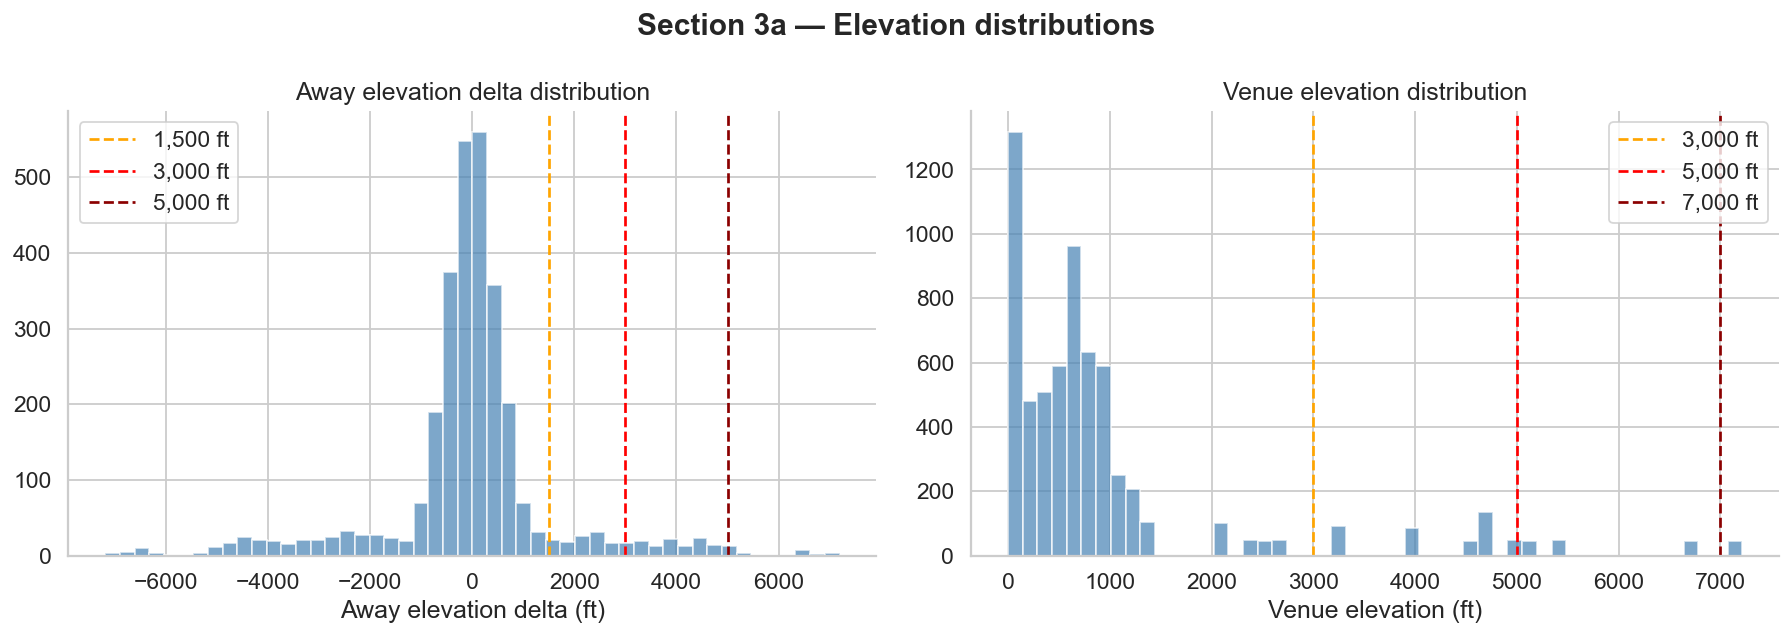

Percentile distribution — away_elevation_delta_ft (away teams only):
  25th pct: -450 ft
  50th pct: -3 ft
  75th pct: 413 ft
  90th pct: 1,121 ft
  95th pct: 2,919 ft
  99th pct: 4,841 ft

Percentile distribution — venue_elevation_ft (all games):
  25th pct: 216 ft
  50th pct: 623 ft
  75th pct: 915 ft
  90th pct: 2,536 ft
  95th pct: 4,636 ft
  99th pct: 6,657 ft


In [41]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(away['away_elevation_delta_ft'].dropna(), bins=50,
             color='steelblue', alpha=0.7, edgecolor='white')
axes[0].axvline(1500, color='orange', lw=1.5, linestyle='--', label='1,500 ft')
axes[0].axvline(3000, color='red',    lw=1.5, linestyle='--', label='3,000 ft')
axes[0].axvline(5000, color='darkred',lw=1.5, linestyle='--', label='5,000 ft')
axes[0].set_xlabel('Away elevation delta (ft)')
axes[0].set_title('Away elevation delta distribution')
axes[0].legend()

axes[1].hist(df['venue_elevation_ft'].dropna(), bins=50,
             color='steelblue', alpha=0.7, edgecolor='white')
axes[1].axvline(3000, color='orange', lw=1.5, linestyle='--', label='3,000 ft')
axes[1].axvline(5000, color='red',    lw=1.5, linestyle='--', label='5,000 ft')
axes[1].axvline(7000, color='darkred',lw=1.5, linestyle='--', label='7,000 ft')
axes[1].set_xlabel('Venue elevation (ft)')
axes[1].set_title('Venue elevation distribution')
axes[1].legend()

plt.suptitle('Section 3a — Elevation distributions', fontweight='bold')
plt.tight_layout()
plt.show()

print("Percentile distribution — away_elevation_delta_ft (away teams only):")
for p in [25, 50, 75, 90, 95, 99]:
    v = np.nanpercentile(away['away_elevation_delta_ft'], p)
    print(f"  {p}th pct: {v:,.0f} ft")

print("\nPercentile distribution — venue_elevation_ft (all games):")
for p in [25, 50, 75, 90, 95, 99]:
    v = np.nanpercentile(df['venue_elevation_ft'], p)
    print(f"  {p}th pct: {v:,.0f} ft")

In [42]:
print("=" * 70)
print("Section 3b — Elevation partial r (away teams only, full population)")
print("=" * 70)

r_venue, p_venue, n_venue = partial_corr(
    away, 'venue_elevation_ft', 'point_differential', EPA_CONTROLS)
r_delta, p_delta, n_delta = partial_corr(
    away, 'away_elevation_delta_ft', 'point_differential', EPA_CONTROLS)
r_home, p_home, n_home = partial_corr(
    away, 'away_home_elevation_ft', 'point_differential', EPA_CONTROLS)

for feat, r, p, n in [
    ('venue_elevation_ft',      r_venue, p_venue, n_venue),
    ('away_elevation_delta_ft', r_delta, p_delta, n_delta),
    ('away_home_elevation_ft',  r_home,  p_home,  n_home),
]:
    flag = '  ← |r|≥0.10' if (not np.isnan(r) and abs(r) >= THRESHOLD) else ''
    print(f"  {feat:<30} r={r:+.4f}  p={p:.4f}  n={n:,}{flag}")

print()
print("Note: away_home_elevation_ft tests whether teams from high-altitude")
print("homes are less affected by elevation at away venues.")

Section 3b — Elevation partial r (away teams only, full population)
  venue_elevation_ft             r=-0.0240  p=0.1893  n=2,995
  away_elevation_delta_ft        r=-0.0132  p=0.4698  n=2,995
  away_home_elevation_ft         r=-0.0073  p=0.6894  n=2,995

Note: away_home_elevation_ft tests whether teams from high-altitude
homes are less affected by elevation at away venues.


In [43]:
print("=" * 70)
print("Section 3c — Elevation threshold analysis (away_elevation_delta_ft)")
print("=" * 70)

elev_threshold_results = []
for threshold in [500, 1000, 1500, 2000, 3000, 5000]:
    res = threshold_partial_corr(
        away, 'away_elevation_delta_ft', threshold,
        label=f'delta >= {threshold:,} ft'
    )
    if res:
        elev_threshold_results.append(res)

Section 3c — Elevation threshold analysis (away_elevation_delta_ft)
  delta >= 500 ft                                    r=-0.0270  p=0.4913  n=653
  delta >= 1,000 ft                                  r=+0.0606  p=0.2724  n=330
  delta >= 1,500 ft                                  r=+0.0455  p=0.4652  n=260
  delta >= 2,000 ft                                  r=+0.0963  p=0.1471  n=228
  delta >= 3,000 ft                                  r=+0.0595  p=0.4786  n=144
  delta >= 5,000 ft                                  r=+nan  p=nan  n=23


In [44]:
print("=" * 70)
print("Section 3d — Home team altitude advantage")
print("=" * 70)

# Get EPA-only residuals for all home teams
resid_vals, resid_idx = ols_resid(home, EPA_CONTROLS)
home_with_resid = home.copy()
home_with_resid = home_with_resid.loc[resid_idx].copy()
home_with_resid['epa_resid'] = resid_vals

for elev_thresh, label in [(3000, '3,000 ft'), (5000, '5,000 ft')]:
    high = home_with_resid[home_with_resid['venue_elevation_ft'] >= elev_thresh]['epa_resid']
    low  = home_with_resid[home_with_resid['venue_elevation_ft'] <  elev_thresh]['epa_resid']

    t_stat, p_val = stats.ttest_ind(high, low, equal_var=False)

    print(f"\nVenue elevation >= {label}:")
    print(f"  High-elev home residual: mean={high.mean():+.3f}  SD={high.std():.3f}  n={len(high):,}")
    print(f"  Sea-level home residual: mean={low.mean():+.3f}   SD={low.std():.3f}  n={len(low):,}")
    print(f"  t={t_stat:+.3f}  p={p_val:.4f}")
    if p_val < 0.05:
        print(f"  → Significant: home teams outperform EPA expectations at altitude")
    else:
        print(f"  → Not significant at p<0.05")

Section 3d — Home team altitude advantage

Venue elevation >= 3,000 ft:
  High-elev home residual: mean=+0.192  SD=8.929  n=320
  Sea-level home residual: mean=-0.019   SD=9.444  n=3,160
  t=+0.402  p=0.6881
  → Not significant at p<0.05

Venue elevation >= 5,000 ft:
  High-elev home residual: mean=-0.623  SD=8.315  n=124
  Sea-level home residual: mean=+0.023   SD=9.434  n=3,356
  t=-0.845  p=0.3998
  → Not significant at p<0.05


In [45]:
print("=" * 70)
print("Section 3e — YoY stability: away_elevation_delta_ft")
print("=" * 70)

# Season-level mean elevation delta per team
elev_yoy = (
    away.groupby(['team_name', 'season'])['away_elevation_delta_ft']
    .mean()
    .reset_index()
)
merged = elev_yoy.merge(
    elev_yoy.rename(columns={'season': 'season_next',
                              'away_elevation_delta_ft': 'delta_next'}),
    on='team_name'
)
merged = merged[merged['season_next'] == merged['season'] + 1]

r_yoy, p_yoy = stats.pearsonr(
    merged['away_elevation_delta_ft'], merged['delta_next'])

print(f"  YoY r = {r_yoy:+.4f}   p = {p_yoy:.4f}   n pairs = {len(merged):,}")
print(f"  Benchmark: off_epa YoY r=0.423, SP+ YoY r=0.761")
if r_yoy < 0.80:
    print(f"  ⚠ UNSTABLE — YoY r below 0.80 threshold")
else:
    print(f"  ✓ STABLE — YoY r above 0.80 threshold")

Section 3e — YoY stability: away_elevation_delta_ft
  YoY r = +0.8633   p = 0.0000   n pairs = 398
  Benchmark: off_epa YoY r=0.423, SP+ YoY r=0.761
  ✓ STABLE — YoY r above 0.80 threshold


In [46]:
print("=" * 70)
print("Section 3f — Conference-stratified elevation (Mountain West + Big 12)")
print("=" * 70)

print("\nFull away population:")
r1, p1, n1 = partial_corr(away, 'away_elevation_delta_ft',
                            'point_differential', EPA_CONTROLS)
print(f"  away_elevation_delta_ft  r={r1:+.4f}  p={p1:.4f}  n={n1:,}")

print("\nMountain West + Big 12 only:")
r2, p2, n2 = partial_corr(away_elev, 'away_elevation_delta_ft',
                            'point_differential', EPA_CONTROLS)
print(f"  away_elevation_delta_ft  r={r2:+.4f}  p={p2:.4f}  n={n2:,}")

print("\nThreshold analysis within Mountain West + Big 12:")
for threshold in [1500, 3000, 5000]:
    threshold_partial_corr(
        away_elev, 'away_elevation_delta_ft', threshold,
        label=f'MW+B12, delta >= {threshold:,} ft'
    )

print(f"\nSignal change: full pop r={r1:+.4f} → MW+B12 r={r2:+.4f}")
if abs(r2) > abs(r1):
    print("  → Signal strengthens in elevation-relevant conferences as expected")
else:
    print("  → Signal does not concentrate in elevation conferences — note this")

Section 3f — Conference-stratified elevation (Mountain West + Big 12)

Full away population:
  away_elevation_delta_ft  r=-0.0132  p=0.4698  n=2,995

Mountain West + Big 12 only:
  away_elevation_delta_ft  r=-0.0098  p=0.8125  n=592

Threshold analysis within Mountain West + Big 12:
  MW+B12, delta >= 1,500 ft                          r=+0.0350  p=0.6901  n=132
  MW+B12, delta >= 3,000 ft                          r=+0.0990  p=0.4185  n=69
  MW+B12, delta >= 5,000 ft                          r=+nan  p=nan  n=14

Signal change: full pop r=-0.0132 → MW+B12 r=-0.0098
  → Signal does not concentrate in elevation conferences — note this


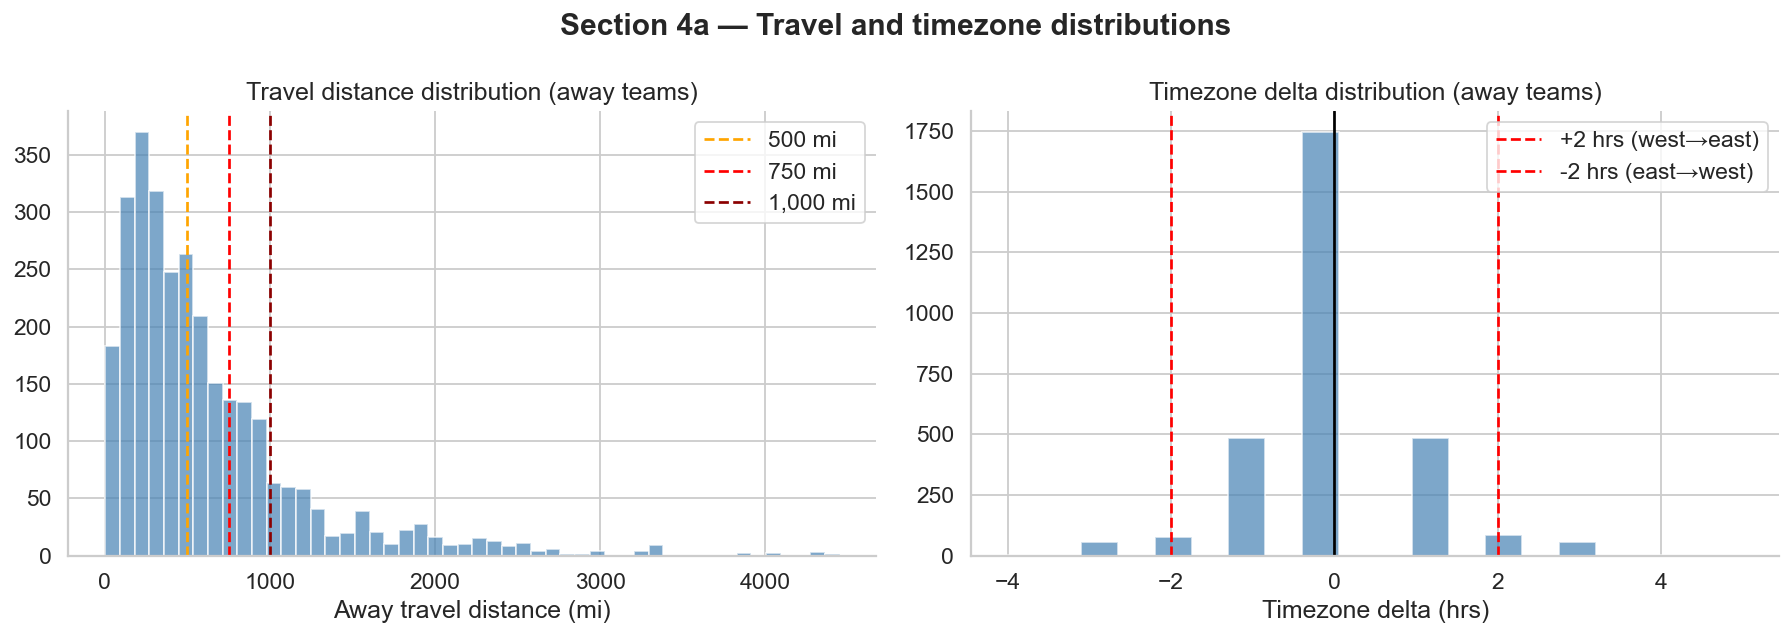

Percentile distribution — away_travel_distance_mi (away teams only):
  25th pct: 240 mi
  50th pct: 455 mi
  75th pct: 817 mi
  90th pct: 1,294 mi
  95th pct: 1,861 mi
  99th pct: 2,759 mi


In [47]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(away['away_travel_distance_mi'].dropna(), bins=50,
             color='steelblue', alpha=0.7, edgecolor='white')
for v, c, l in [(500,'orange','500 mi'),(750,'red','750 mi'),(1000,'darkred','1,000 mi')]:
    axes[0].axvline(v, color=c, lw=1.5, linestyle='--', label=l)
axes[0].set_xlabel('Away travel distance (mi)')
axes[0].set_title('Travel distance distribution (away teams)')
axes[0].legend()

axes[1].hist(away['away_tz_delta_hrs'].dropna(), bins=20,
             color='steelblue', alpha=0.7, edgecolor='white')
axes[1].axvline(0, color='black', lw=1.5, linestyle='-')
axes[1].axvline(2,  color='red',  lw=1.5, linestyle='--', label='+2 hrs (west→east)')
axes[1].axvline(-2, color='red',  lw=1.5, linestyle='--', label='-2 hrs (east→west)')
axes[1].set_xlabel('Timezone delta (hrs)')
axes[1].set_title('Timezone delta distribution (away teams)')
axes[1].legend()

plt.suptitle('Section 4a — Travel and timezone distributions', fontweight='bold')
plt.tight_layout()
plt.show()

print("Percentile distribution — away_travel_distance_mi (away teams only):")
for p in [25, 50, 75, 90, 95, 99]:
    v = np.nanpercentile(away['away_travel_distance_mi'], p)
    print(f"  {p}th pct: {v:,.0f} mi")

In [48]:
print("=" * 70)
print("Section 4b — Travel partial r (away teams only, full population)")
print("=" * 70)

r_dist, p_dist, n_dist = partial_corr(
    away, 'away_travel_distance_mi', 'point_differential', EPA_CONTROLS)
r_tz, p_tz, n_tz = partial_corr(
    away, 'away_tz_delta_hrs', 'point_differential', EPA_CONTROLS)

for feat, r, p, n in [
    ('away_travel_distance_mi', r_dist, p_dist, n_dist),
    ('away_tz_delta_hrs',       r_tz,   p_tz,   n_tz),
]:
    flag = '  ← |r|≥0.10' if (not np.isnan(r) and abs(r) >= THRESHOLD) else ''
    print(f"  {feat:<30} r={r:+.4f}  p={p:.4f}  n={n:,}{flag}")

Section 4b — Travel partial r (away teams only, full population)
  away_travel_distance_mi        r=-0.0184  p=0.3175  n=2,942
  away_tz_delta_hrs              r=-0.0170  p=0.3514  n=2,995


In [49]:
print("=" * 70)
print("Section 4c — Travel threshold analysis (away_travel_distance_mi)")
print("=" * 70)

travel_threshold_results = []
for threshold in [300, 500, 750, 1000, 1500]:
    res = threshold_partial_corr(
        away, 'away_travel_distance_mi', threshold,
        label=f'travel >= {threshold:,} mi'
    )
    if res:
        travel_threshold_results.append(res)

Section 4c — Travel threshold analysis (away_travel_distance_mi)
  travel >= 300 mi                                   r=-0.0091  p=0.6855  n=1,981
  travel >= 500 mi                                   r=-0.0187  p=0.4911  n=1,356
  travel >= 750 mi                                   r=+0.0212  p=0.5407  n=832
  travel >= 1,000 mi                                 r=+0.0400  p=0.3789  n=485
  travel >= 1,500 mi                                 r=+0.0550  p=0.3923  n=244


In [50]:
print("=" * 70)
print("Section 4d — Direction of travel interaction (travel >= 500 mi)")
print("=" * 70)

for direction in ['east', 'west', 'neutral']:
    sub = away_500[away_500['travel_direction'] == direction]
    if len(sub) < 30:
        print(f"  {direction:<10} n={len(sub):,}  — insufficient sample")
        continue
    mean_diff = sub['point_differential'].mean()
    r, p, n   = partial_corr(sub, 'away_travel_distance_mi',
                              'point_differential', EPA_CONTROLS)
    print(f"  {direction:<10} n={n:,}  mean_pt_diff={mean_diff:+.3f}  "
          f"partial_r={r:+.4f}  p={p:.4f}")

east_mean = away_500[away_500['travel_direction']=='east']['point_differential'].mean()
west_mean = away_500[away_500['travel_direction']=='west']['point_differential'].mean()
gap = east_mean - west_mean
print(f"\n  East vs West gap: {gap:+.3f} points")
if abs(gap) > 2.0:
    print(f"  ⚠ East-traveling teams underperform west-traveling by >{abs(gap):.1f} pts")
else:
    print(f"  → Gap within 2-point threshold — direction effect modest")

Section 4d — Direction of travel interaction (travel >= 500 mi)
  east       n=491  mean_pt_diff=-4.589  partial_r=-0.0560  p=0.2151
  west       n=480  mean_pt_diff=-6.073  partial_r=+0.0666  p=0.1450
  neutral    n=385  mean_pt_diff=-4.252  partial_r=-0.0226  p=0.6585

  East vs West gap: +1.484 points
  → Gap within 2-point threshold — direction effect modest


In [51]:
print("=" * 70)
print("Section 4e — Timezone threshold analysis")
print("=" * 70)

for tz_thresh in [1, 2, 3]:
    sub = away[away['away_tz_delta_hrs'] >= tz_thresh]
    r, p, n = partial_corr(sub, 'away_tz_delta_hrs',
                            'point_differential', EPA_CONTROLS)
    flag = '  ← |r|≥0.10' if (not np.isnan(r) and abs(r) >= THRESHOLD) else ''
    print(f"  tz_delta >= +{tz_thresh} hrs (traveling east)  "
          f"r={r:+.4f}  p={p:.4f}  n={n:,}{flag}")

print()
for tz_thresh in [1, 2, 3]:
    sub = away[away['away_tz_delta_hrs'] <= -tz_thresh]
    r, p, n = partial_corr(sub, 'away_tz_delta_hrs',
                            'point_differential', EPA_CONTROLS)
    flag = '  ← |r|≥0.10' if (not np.isnan(r) and abs(r) >= THRESHOLD) else ''
    print(f"  tz_delta <= -{tz_thresh} hrs (traveling west)  "
          f"r={r:+.4f}  p={p:.4f}  n={n:,}{flag}")

Section 4e — Timezone threshold analysis
  tz_delta >= +1 hrs (traveling east)  r=-0.0605  p=0.1304  n=626
  tz_delta >= +2 hrs (traveling east)  r=-0.0764  p=0.3644  n=143
  tz_delta >= +3 hrs (traveling east)  r=+0.0014  p=0.9914  n=59

  tz_delta <= -1 hrs (traveling west)  r=-0.0269  p=0.5028  n=622
  tz_delta <= -2 hrs (traveling west)  r=-0.1099  p=0.2010  n=137  ← |r|≥0.10
  tz_delta <= -3 hrs (traveling west)  r=-0.1199  p=0.3573  n=61  ← |r|≥0.10


In [52]:
print("=" * 70)
print("Section 4f — Maximum stress population (travel>=500mi AND |tz|>=2hrs)")
print("=" * 70)

print(f"  Population size: {len(away_max_stress):,}")

r_dist, p_dist, n_dist = partial_corr(
    away_max_stress, 'away_travel_distance_mi',
    'point_differential', EPA_CONTROLS)
r_tz, p_tz, n_tz = partial_corr(
    away_max_stress, 'away_tz_delta_hrs',
    'point_differential', EPA_CONTROLS)

print(f"  away_travel_distance_mi  r={r_dist:+.4f}  p={p_dist:.4f}  n={n_dist:,}")
print(f"  away_tz_delta_hrs        r={r_tz:+.4f}    p={p_tz:.4f}    n={n_tz:,}")

mean_diff = away_max_stress['point_differential'].mean()
full_mean = away['point_differential'].mean()
print(f"\n  Max stress mean pt diff:  {mean_diff:+.3f}")
print(f"  All away mean pt diff:    {full_mean:+.3f}")
print(f"  Additional disadvantage:  {mean_diff - full_mean:+.3f} points")

Section 4f — Maximum stress population (travel>=500mi AND |tz|>=2hrs)
  Population size: 273
  away_travel_distance_mi  r=+0.1017  p=0.0934  n=273
  away_tz_delta_hrs        r=-0.0964    p=0.1120    n=273

  Max stress mean pt diff:  -6.912
  All away mean pt diff:    -4.514
  Additional disadvantage:  -2.398 points


In [53]:
print("=" * 70)
print("Section 4g — YoY stability: away_travel_distance_mi")
print("=" * 70)

trav_yoy = (
    away.groupby(['team_name', 'season'])['away_travel_distance_mi']
    .mean()
    .reset_index()
)
merged_t = trav_yoy.merge(
    trav_yoy.rename(columns={'season': 'season_next',
                              'away_travel_distance_mi': 'dist_next'}),
    on='team_name'
)
merged_t = merged_t[merged_t['season_next'] == merged_t['season'] + 1]
merged_t = merged_t.dropna(subset=['away_travel_distance_mi', 'dist_next'])

r_yoy_t, p_yoy_t = stats.pearsonr(
    merged_t['away_travel_distance_mi'], merged_t['dist_next'])

print(f"  YoY r = {r_yoy_t:+.4f}   p = {p_yoy_t:.4f}   n pairs = {len(merged_t):,}")
print(f"  Benchmark: off_epa YoY r=0.423, SP+ YoY r=0.761")
if r_yoy_t < 0.80:
    print(f"  ⚠ UNSTABLE — YoY r below 0.80 threshold")
else:
    print(f"  ✓ STABLE — YoY r above 0.80 threshold")

print()
print("Note: Travel distance YoY stability reflects schedule geography.")
print("Teams in geographically large conferences travel similar distances")
print("year over year — high YoY r expected for Big Ten, Big 12.")

Section 4g — YoY stability: away_travel_distance_mi
  YoY r = +0.7229   p = 0.0000   n pairs = 391
  Benchmark: off_epa YoY r=0.423, SP+ YoY r=0.761
  ⚠ UNSTABLE — YoY r below 0.80 threshold

Note: Travel distance YoY stability reflects schedule geography.
Teams in geographically large conferences travel similar distances
year over year — high YoY r expected for Big Ten, Big 12.


In [54]:
print("=" * 70)
print("Section 4h — Conference-stratified travel (Big Ten + Big 12)")
print("=" * 70)

print("\nFull away population:")
r1, p1, n1 = partial_corr(away, 'away_travel_distance_mi',
                            'point_differential', EPA_CONTROLS)
print(f"  away_travel_distance_mi  r={r1:+.4f}  p={p1:.4f}  n={n1:,}")

print("\nBig Ten + Big 12 only:")
r2, p2, n2 = partial_corr(away_trav, 'away_travel_distance_mi',
                            'point_differential', EPA_CONTROLS)
print(f"  away_travel_distance_mi  r={r2:+.4f}  p={p2:.4f}  n={n2:,}")

print("\nThreshold analysis within Big Ten + Big 12:")
for threshold in [500, 750, 1000]:
    threshold_partial_corr(
        away_trav, 'away_travel_distance_mi', threshold,
        label=f'B10+B12, travel >= {threshold:,} mi'
    )

Section 4h — Conference-stratified travel (Big Ten + Big 12)

Full away population:
  away_travel_distance_mi  r=-0.0184  p=0.3175  n=2,942

Big Ten + Big 12 only:
  away_travel_distance_mi  r=-0.0543  p=0.1789  n=615

Threshold analysis within Big Ten + Big 12:
  B10+B12, travel >= 500 mi                          r=-0.0502  p=0.3738  n=316
  B10+B12, travel >= 750 mi                          r=-0.0150  p=0.8307  n=205
  B10+B12, travel >= 1,000 mi                        r=+0.0539  p=0.5460  n=128


In [55]:
print("=" * 70)
print("Section 4i — Kickoff time and timezone interaction")
print("=" * 70)

print("\nKickoff bucket distribution (FBS games):")
print(df['kickoff_bucket'].value_counts().sort_index())

print("\nFor west-to-east travelers (tz_delta >= 1), performance by kickoff:")
east_travelers = away[away['away_tz_delta_hrs'] >= 1].copy()

bucket_order = ['early', 'noon', 'afternoon', 'evening', 'night']
print(f"\n  {'bucket':<12} {'n':>5}  {'mean_pt_diff':>13}  {'epa_resid':>10}")
print(f"  {'-'*50}")

resid_vals, resid_idx = ols_resid(east_travelers, EPA_CONTROLS)
east_travelers_r = east_travelers.loc[resid_idx].copy()
east_travelers_r['epa_resid'] = resid_vals

for bucket in bucket_order:
    sub = east_travelers_r[east_travelers_r['kickoff_bucket'] == bucket]
    if len(sub) < 10:
        print(f"  {bucket:<12} {len(sub):>5}  — insufficient sample")
        continue
    mean_diff  = sub['point_differential'].mean()
    mean_resid = sub['epa_resid'].mean()
    print(f"  {bucket:<12} {len(sub):>5}  {mean_diff:>+13.3f}  {mean_resid:>+10.3f}")

print()
print("For all away teams, performance by kickoff bucket:")
print(f"\n  {'bucket':<12} {'n':>5}  {'mean_pt_diff':>13}")
print(f"  {'-'*40}")
for bucket in bucket_order:
    sub = away[away['kickoff_bucket'] == bucket]
    if len(sub) < 10:
        continue
    print(f"  {bucket:<12} {len(sub):>5}  {sub['point_differential'].mean():>+13.3f}")

print()
print("Key question: do early kickoffs hurt east-traveling teams more than night games?")
if len(east_travelers_r) > 0:
    early_r = east_travelers_r[east_travelers_r['kickoff_bucket'].isin(['early','noon'])]['epa_resid'].mean()
    night_r = east_travelers_r[east_travelers_r['kickoff_bucket'].isin(['evening','night'])]['epa_resid'].mean()
    print(f"  Early/noon EPA resid:    {early_r:+.3f}")
    print(f"  Evening/night EPA resid: {night_r:+.3f}")
    print(f"  Gap: {early_r - night_r:+.3f} points")
    if (early_r - night_r) < -1.5:
        print(f"  ⚠ Early kickoffs hurt east-traveling teams by >{abs(early_r-night_r):.1f} pts vs night games")
    else:
        print(f"  → Kickoff time interaction modest within this dataset")

Section 4i — Kickoff time and timezone interaction

Kickoff bucket distribution (FBS games):
kickoff_bucket
afternoon    2254
early          22
evening      1566
night        1395
noon         1238
Name: count, dtype: int64

For west-to-east travelers (tz_delta >= 1), performance by kickoff:

  bucket           n   mean_pt_diff   epa_resid
  --------------------------------------------------
  early            1  — insufficient sample
  noon           125         -1.992      +0.418
  afternoon      227         -6.062      -0.640
  evening        173         -2.936      +0.496
  night          100         -7.590      +0.145

For all away teams, performance by kickoff bucket:

  bucket           n   mean_pt_diff
  ----------------------------------------
  early           10         -7.700
  noon           587         -2.850
  afternoon     1054         -4.858
  evening        688         -5.158
  night          656         -4.726

Key question: do early kickoffs hurt east-traveling team

In [56]:
print("=" * 70)
print("Section 5a — Temperature (non-dome games only)")
print("=" * 70)

r_temp, p_temp, n_temp = partial_corr(
    non_dome, 'temperature_f', 'point_differential', EPA_CONTROLS)
print(f"  temperature_f partial r = {r_temp:+.4f}  p={p_temp:.4f}  n={n_temp:,}")

print("\nTemperature bins — mean pt_diff and EPA residual:")
resid_vals_nd, resid_idx_nd = ols_resid(non_dome, EPA_CONTROLS)
non_dome_r = non_dome.loc[resid_idx_nd].copy()
non_dome_r['epa_resid'] = resid_vals_nd

bins = [
    ('cold',     non_dome_r['temperature_f'] <  40),
    ('cool',    (non_dome_r['temperature_f'] >= 40) & (non_dome_r['temperature_f'] < 55)),
    ('moderate',(non_dome_r['temperature_f'] >= 55) & (non_dome_r['temperature_f'] < 75)),
    ('warm',    (non_dome_r['temperature_f'] >= 75) & (non_dome_r['temperature_f'] < 90)),
    ('hot',      non_dome_r['temperature_f'] >= 90),
]

print(f"\n  {'bin':<12} {'n':>5}  {'mean_pt_diff':>13}  {'epa_resid':>10}")
print(f"  {'-'*50}")
moderate_resid = non_dome_r[
    (non_dome_r['temperature_f'] >= 55) &
    (non_dome_r['temperature_f'] < 75)
]['epa_resid'].mean()

for label, mask in bins:
    sub = non_dome_r[mask]
    if len(sub) < 5:
        print(f"  {label:<12} {len(sub):>5}  — insufficient sample")
        continue
    mean_diff  = sub['point_differential'].mean()
    mean_resid = sub['epa_resid'].mean()
    flag = '  ⚠' if abs(mean_resid - moderate_resid) > 2.0 else ''
    print(f"  {label:<12} {len(sub):>5}  {mean_diff:>+13.3f}  {mean_resid:>+10.3f}{flag}")

Section 5a — Temperature (non-dome games only)
  temperature_f partial r = +0.0250  p=0.0485  n=6,218

Temperature bins — mean pt_diff and EPA residual:

  bin              n   mean_pt_diff   epa_resid
  --------------------------------------------------
  cold           303         +0.086      -0.285
  cool          1005         +0.458      -0.285
  moderate      2682         +1.412      -0.123
  warm          2023         +4.686      +0.347
  hot            205         +4.156      +0.015


In [57]:
print("=" * 70)
print("Section 5b — Wind speed (non-dome games only)")
print("=" * 70)

r_wind, p_wind, n_wind = partial_corr(
    non_dome, 'wind_speed_mph', 'point_differential', EPA_CONTROLS)

non_dome_hw = non_dome.copy()
non_dome_hw['is_high_wind_num'] = non_dome_hw['is_high_wind'].map(
    lambda x: 1 if x is True else (0 if x is False else np.nan)
).astype(float)

r_hw, p_hw, n_hw = partial_corr(
    non_dome_hw, 'is_high_wind_num', 'point_differential', EPA_CONTROLS)

print(f"  wind_speed_mph partial r  = {r_wind:+.4f}  p={p_wind:.4f}  n={n_wind:,}")
print(f"  is_high_wind partial r    = {r_hw:+.4f}    p={p_hw:.4f}    n={n_hw:,}")

hw     = non_dome[non_dome['is_high_wind'] == True]
non_hw = non_dome[non_dome['is_high_wind'] == False]

hw_pts     = (hw['points_scored'] + hw['points_allowed']).mean()
non_hw_pts = (non_hw['points_scored'] + non_hw['points_allowed']).mean()

print(f"\n  High wind games total pts/game:     {hw_pts:.2f}  (n={len(hw):,})")
print(f"  Non-high wind games total pts/game: {non_hw_pts:.2f}  (n={len(non_hw):,})")
gap = hw_pts - non_hw_pts
print(f"  Gap: {gap:+.2f} pts")
if abs(gap) > 3:
    print(f"  ⚠ High wind suppresses scoring by >{abs(gap):.1f} pts/game")
else:
    print(f"  → Scoring difference within 3-point threshold")

Section 5b — Wind speed (non-dome games only)
  wind_speed_mph partial r  = -0.0081  p=0.5221  n=6,218
  is_high_wind partial r    = -0.0032    p=0.8033    n=6,218

  High wind games total pts/game:     51.27  (n=645)
  Non-high wind games total pts/game: 53.89  (n=5,573)
  Gap: -2.61 pts
  → Scoring difference within 3-point threshold


In [58]:
print("=" * 70)
print("Section 5c — Humidity (non-dome games only)")
print("=" * 70)

r_hum, p_hum, n_hum = partial_corr(
    non_dome, 'humidity_pct', 'point_differential', EPA_CONTROLS)
print(f"  humidity_pct partial r = {r_hum:+.4f}  p={p_hum:.4f}  n={n_hum:,}")

print("\nHumidity bins:")
hum_bins = [
    ('dry',       non_dome['humidity_pct'] <  30),
    ('moderate', (non_dome['humidity_pct'] >= 30) & (non_dome['humidity_pct'] < 60)),
    ('humid',    (non_dome['humidity_pct'] >= 60) & (non_dome['humidity_pct'] < 80)),
    ('very_humid',non_dome['humidity_pct'] >= 80),
]

print(f"\n  {'bin':<12} {'n':>5}  {'mean_pt_diff':>13}")
print(f"  {'-'*35}")
for label, mask in hum_bins:
    sub = non_dome[mask]
    print(f"  {label:<12} {len(sub):>5}  {sub['point_differential'].mean():>+13.3f}")

Section 5c — Humidity (non-dome games only)
  humidity_pct partial r = +0.0032  p=0.7992  n=6,218

Humidity bins:

  bin              n   mean_pt_diff
  -----------------------------------
  dry            482         +2.313
  moderate      3201         +2.428
  humid         1795         +2.184
  very_humid     740         +2.431


In [59]:
print("=" * 70)
print("Section 5d — Wind chill composite vs components")
print("=" * 70)

wc_pop = non_dome[non_dome['wind_chill'].notna()].copy()
print(f"  Wind chill population (temp<50 AND wind>3): {len(wc_pop):,} games")

r_wc,   p_wc,   n_wc   = partial_corr(wc_pop, 'wind_chill',    'point_differential', EPA_CONTROLS)
r_t_wc, p_t_wc, n_t_wc = partial_corr(wc_pop, 'temperature_f', 'point_differential', EPA_CONTROLS)
r_w_wc, p_w_wc, n_w_wc = partial_corr(wc_pop, 'wind_speed_mph','point_differential', EPA_CONTROLS)

print(f"\n  Within wind chill population:")
print(f"  wind_chill    partial r = {r_wc:+.4f}   p={p_wc:.4f}   n={n_wc:,}")
print(f"  temperature_f partial r = {r_t_wc:+.4f}  p={p_t_wc:.4f}  n={n_t_wc:,}")
print(f"  wind_speed_mph partial r= {r_w_wc:+.4f}  p={p_w_wc:.4f}  n={n_w_wc:,}")

print(f"\n  Does wind_chill explain more than temperature alone?")
if not np.isnan(r_wc) and not np.isnan(r_t_wc):
    if abs(r_wc) > abs(r_t_wc):
        print(f"  → Yes: wind_chill r={r_wc:+.4f} > temperature r={r_t_wc:+.4f}")
        print(f"     Use wind_chill as the composite in the model")
    else:
        print(f"  → No: temperature r={r_t_wc:+.4f} ≥ wind_chill r={r_wc:+.4f}")
        print(f"     temperature_f alone captures the cold weather signal")

print("\nWind chill thresholds:")
for wc_thresh in [40, 25, 10]:
    sub = wc_pop[wc_pop['wind_chill'] <= wc_thresh]
    if len(sub) < 10:
        print(f"  wind_chill <= {wc_thresh}F: n={len(sub)} — insufficient sample")
        continue
    mean_pts = (sub['points_scored'] + sub['points_allowed']).mean()
    mean_diff = sub['point_differential'].mean()
    print(f"  wind_chill <= {wc_thresh}F: n={len(sub):,}  "
          f"total_pts={mean_pts:.1f}  mean_pt_diff={mean_diff:+.3f}")

Section 5d — Wind chill composite vs components
  Wind chill population (temp<50 AND wind>3): 6,218 games

  Within wind chill population:
  wind_chill    partial r = +0.0243   p=0.0557   n=6,218
  temperature_f partial r = +0.0250  p=0.0485  n=6,218
  wind_speed_mph partial r= -0.0081  p=0.5221  n=6,218

  Does wind_chill explain more than temperature alone?
  → No: temperature r=+0.0250 ≥ wind_chill r=+0.0243
     temperature_f alone captures the cold weather signal

Wind chill thresholds:
  wind_chill <= 40F: n=470  total_pts=50.5  mean_pt_diff=+0.181
  wind_chill <= 25F: n=108  total_pts=47.6  mean_pt_diff=+0.000
  wind_chill <= 10F: n=10  total_pts=42.8  mean_pt_diff=+0.000


In [60]:
print("=" * 70)
print("Section 5e — Heat index composite vs components")
print("=" * 70)

hi_pop = non_dome[non_dome['heat_index'].notna()].copy()
print(f"  Heat index population (temp>80 AND humidity>40): {len(hi_pop):,} games")

r_hi,   p_hi,   n_hi   = partial_corr(hi_pop, 'heat_index',   'point_differential', EPA_CONTROLS)
r_t_hi, p_t_hi, n_t_hi = partial_corr(hi_pop, 'temperature_f','point_differential', EPA_CONTROLS)
r_h_hi, p_h_hi, n_h_hi = partial_corr(hi_pop, 'humidity_pct', 'point_differential', EPA_CONTROLS)

print(f"\n  Within heat index population:")
print(f"  heat_index    partial r = {r_hi:+.4f}   p={p_hi:.4f}   n={n_hi:,}")
print(f"  temperature_f partial r = {r_t_hi:+.4f}  p={p_t_hi:.4f}  n={n_t_hi:,}")
print(f"  humidity_pct  partial r = {r_h_hi:+.4f}  p={p_h_hi:.4f}  n={n_h_hi:,}")

print(f"\n  Does heat_index explain more than temperature alone?")
if not np.isnan(r_hi) and not np.isnan(r_t_hi):
    if abs(r_hi) > abs(r_t_hi):
        print(f"  → Yes: heat_index r={r_hi:+.4f} > temperature r={r_t_hi:+.4f}")
        print(f"     Use heat_index as the composite in the model")
    else:
        print(f"  → No: temperature r={r_t_hi:+.4f} ≥ heat_index r={r_hi:+.4f}")
        print(f"     temperature_f alone captures the heat signal")

print("\nHeat index thresholds:")
for hi_thresh in [90, 100, 105]:
    sub = hi_pop[hi_pop['heat_index'] >= hi_thresh]
    if len(sub) < 10:
        print(f"  heat_index >= {hi_thresh}F: n={len(sub)} — insufficient sample")
        continue
    mean_pts  = (sub['points_scored'] + sub['points_allowed']).mean()
    mean_diff = sub['point_differential'].mean()
    print(f"  heat_index >= {hi_thresh}F: n={len(sub):,}  "
          f"total_pts={mean_pts:.1f}  mean_pt_diff={mean_diff:+.3f}")

Section 5e — Heat index composite vs components
  Heat index population (temp>80 AND humidity>40): 6,218 games

  Within heat index population:
  heat_index    partial r = +0.0266   p=0.0356   n=6,218
  temperature_f partial r = +0.0250  p=0.0485  n=6,218
  humidity_pct  partial r = +0.0032  p=0.7992  n=6,218

  Does heat_index explain more than temperature alone?
  → Yes: heat_index r=+0.0266 > temperature r=+0.0250
     Use heat_index as the composite in the model

Heat index thresholds:
  heat_index >= 90F: n=327  total_pts=54.7  mean_pt_diff=+6.300
  heat_index >= 100F: n=17  total_pts=53.1  mean_pt_diff=+4.941
  heat_index >= 105F: n=4 — insufficient sample


In [61]:
print("=" * 70)
print("Section 5f — Precipitation")
print("=" * 70)

n_precip = non_dome['is_precipitation'].map(lambda x: x is True).sum()
print(f"  Precipitation games (non-dome): {int(n_precip):,}")

if n_precip < 100:
    print(f"  ⚠ INSUFFICIENT SAMPLE — n={int(n_precip)} < 100 threshold")
    print(f"  Reporting partial r but do not include as model adjuster")
    print(f"  unless |r| >= 0.10 AND n >= 200 in future data")

non_dome_p = non_dome.copy()
non_dome_p['is_precipitation_num'] = non_dome_p['is_precipitation'].map(
    lambda x: 1 if x is True else (0 if x is False else np.nan)
).astype(float)

r_p, p_p, n_p = partial_corr(
    non_dome_p, 'is_precipitation_num', 'point_differential', EPA_CONTROLS)
print(f"\n  is_precipitation partial r = {r_p:+.4f}  p={p_p:.4f}  n={n_p:,}")

precip_games    = non_dome[non_dome['is_precipitation'].map(lambda x: x is True)]
no_precip_games = non_dome[non_dome['is_precipitation'].map(lambda x: x is False)]

precip_pts    = (precip_games['points_scored']    + precip_games['points_allowed']).mean()
no_precip_pts = (no_precip_games['points_scored'] + no_precip_games['points_allowed']).mean()

print(f"\n  Precip games total pts/game:    {precip_pts:.2f}  (n={len(precip_games):,})")
print(f"  No-precip games total pts/game: {no_precip_pts:.2f}  (n={len(no_precip_games):,})")
print(f"  Gap: {precip_pts - no_precip_pts:+.2f} pts")

Section 5f — Precipitation
  Precipitation games (non-dome): 113

  is_precipitation partial r = -0.0014  p=0.9141  n=6,218

  Precip games total pts/game:    50.02  (n=113)
  No-precip games total pts/game: 53.68  (n=6,105)
  Gap: -3.67 pts


In [62]:
print("=" * 70)
print("Section 5g — Dome vs non-dome")
print("=" * 70)

dome    = df[df['is_dome'].map(lambda x: x is True)].copy()
no_dome = df[df['is_dome'].map(lambda x: x is False)].copy()

r_dome, _, resid_dome_idx   = ols_resid(dome,    EPA_CONTROLS), None, None
r_nodm, _, resid_nodm_idx   = ols_resid(no_dome, EPA_CONTROLS), None, None

resid_dome, _  = ols_resid(dome,    EPA_CONTROLS)
resid_nodome, _ = ols_resid(no_dome, EPA_CONTROLS)

sd_dome   = float(np.std(resid_dome,   ddof=3))
sd_nodome = float(np.std(resid_nodome, ddof=3))

print(f"  Dome games:     n={len(dome):,}  EPA residual SD = {sd_dome:.3f}")
print(f"  Non-dome games: n={len(no_dome):,}  EPA residual SD = {sd_nodome:.3f}")
print(f"  Difference: {sd_dome - sd_nodome:+.3f} points")

if abs(sd_dome - sd_nodome) > 2.0:
    print(f"  ⚠ Residual SD differs by > 2 points — dome flag belongs in model")
else:
    print(f"  → Residual SD within 2-point threshold")

dome_pts   = (dome['points_scored']    + dome['points_allowed']).mean()
nodome_pts = (no_dome['points_scored'] + no_dome['points_allowed']).mean()
print(f"\n  Dome mean total pts/game:     {dome_pts:.2f}")
print(f"  Non-dome mean total pts/game: {nodome_pts:.2f}")
print(f"  Gap: {dome_pts - nodome_pts:+.2f} pts")

Section 5g — Dome vs non-dome
  Dome games:     n=217  EPA residual SD = 10.106
  Non-dome games: n=6,258  EPA residual SD = 9.416
  Difference: +0.690 points
  → Residual SD within 2-point threshold

  Dome mean total pts/game:     56.36
  Non-dome mean total pts/game: 53.57
  Gap: +2.79 pts


In [63]:
print("=" * 70)
print("Section 5h — Weather vs total scoring (over/under relevance)")
print("=" * 70)
print("Controls: sum of both teams' off_epa_per_play")
print("Target: total_points (points_scored + points_allowed)")
print()

# Build game-level total scoring dataframe
# Each game appears twice in df (once per team) — deduplicate to game level
game_totals = (
    df[~df['is_dome'].map(lambda x: x is True)]  # non-dome only first
    .groupby('game_id')
    .agg(
        total_points    = ('points_scored', lambda x: x.sum()),
        sum_off_epa     = ('off_epa_per_play', lambda x: x.sum()),
        sum_def_epa     = ('def_epa_per_play_allowed', lambda x: x.sum()),
        temperature_f   = ('temperature_f', 'first'),
        wind_speed_mph  = ('wind_speed_mph', 'first'),
        humidity_pct    = ('humidity_pct', 'first'),
        wind_chill      = ('wind_chill', 'first'),
        heat_index      = ('heat_index', 'first'),
        is_high_wind    = ('is_high_wind', 'first'),
        is_precipitation= ('is_precipitation', 'first'),
        is_dome         = ('is_dome', 'first'),
    )
    .reset_index()
)

game_totals['is_high_wind_num'] = game_totals['is_high_wind'].map(
    lambda x: 1 if x is True else (0 if x is False else np.nan)).astype(float)
game_totals['is_precipitation_num'] = game_totals['is_precipitation'].map(
    lambda x: 1 if x is True else (0 if x is False else np.nan)).astype(float)

TOTAL_CONTROLS = ['sum_off_epa', 'sum_def_epa']

print(f"  Non-dome game-level rows: {len(game_totals):,}")
print(f"  Mean total points/game:   {game_totals['total_points'].mean():.2f}")
print()

weather_features = [
    ('temperature_f',        'temperature_f'),
    ('wind_speed_mph',       'wind_speed_mph'),
    ('humidity_pct',         'humidity_pct'),
    ('wind_chill',           'wind_chill'),
    ('heat_index',           'heat_index'),
    ('is_high_wind',         'is_high_wind_num'),
    ('is_precipitation',     'is_precipitation_num'),
]

print(f"  {'feature':<25} {'partial_r':>10}  {'p':>7}  {'n':>6}  flag")
print(f"  {'-'*65}")

total_scoring_results = {}
for feat_label, feat_col in weather_features:
    r, p, n = partial_corr(game_totals, feat_col, 'total_points', TOTAL_CONTROLS)
    flag = '  ← |r|≥0.10' if (not np.isnan(r) and abs(r) >= THRESHOLD) else ''
    print(f"  {feat_label:<25} {r:>+10.4f}  {p:>7.4f}  {n:>6,}{flag}")
    total_scoring_results[feat_label] = {'r': r, 'p': p, 'n': n}

print()
print("Interpretation: partial r here tests whether weather affects TOTAL")
print("scoring beyond what team quality (EPA) already predicts.")
print("This is the over/under relevance test — distinct from the spread test.")

Section 5h — Weather vs total scoring (over/under relevance)
Controls: sum of both teams' off_epa_per_play
Target: total_points (points_scored + points_allowed)

  Non-dome game-level rows: 3,366
  Mean total points/game:   51.98

  feature                    partial_r        p       n  flag
  -----------------------------------------------------------------
  temperature_f                -0.0244   0.1576   3,344
  wind_speed_mph               +0.0072   0.6789   3,344
  humidity_pct                 -0.0006   0.9734   3,344
  wind_chill                   -0.0225   0.1929   3,344
  heat_index                   -0.0247   0.1527   3,344
  is_high_wind                 +0.0154   0.3724   3,344
  is_precipitation             -0.0121   0.4856   3,344

Interpretation: partial r here tests whether weather affects TOTAL
scoring beyond what team quality (EPA) already predicts.
This is the over/under relevance test — distinct from the spread test.


In [64]:
print("=" * 70)
print("Section 5i — Weather vs individual team scoring")
print("=" * 70)
print("Controls: team's own off_epa_per_play")
print("Target: points_scored (individual team)")
print()

# Use non-dome games, all rows (both teams per game)
nd = df[~df['is_dome'].map(lambda x: x is True)].copy()
nd['is_high_wind_num'] = nd['is_high_wind'].map(
    lambda x: 1 if x is True else (0 if x is False else np.nan)).astype(float)
nd['is_precipitation_num'] = nd['is_precipitation'].map(
    lambda x: 1 if x is True else (0 if x is False else np.nan)).astype(float)

IND_CONTROLS = ['off_epa_per_play']

weather_features_ind = [
    ('temperature_f',        'temperature_f'),
    ('wind_speed_mph',       'wind_speed_mph'),
    ('humidity_pct',         'humidity_pct'),
    ('wind_chill',           'wind_chill'),
    ('heat_index',           'heat_index'),
    ('is_high_wind',         'is_high_wind_num'),
    ('is_precipitation',     'is_precipitation_num'),
]

print(f"  {'feature':<25} {'partial_r':>10}  {'p':>7}  {'n':>6}  flag")
print(f"  {'-'*65}")

ind_scoring_results = {}
for feat_label, feat_col in weather_features_ind:
    r, p, n = partial_corr(nd, feat_col, 'points_scored', IND_CONTROLS)
    flag = '  ← |r|≥0.10' if (not np.isnan(r) and abs(r) >= THRESHOLD) else ''
    print(f"  {feat_label:<25} {r:>+10.4f}  {p:>7.4f}  {n:>6,}{flag}")
    ind_scoring_results[feat_label] = {'r': r, 'p': p, 'n': n}

print()

# Compare home vs away suppression for top weather features
print("Home vs away scoring suppression by weather condition:")
print("(Tests whether weather creates asymmetric effects)")
print()

for condition, col, threshold_val in [
    ('is_high_wind',    'is_high_wind',    True),
    ('is_precipitation','is_precipitation', True),
]:
    home_cond = df[
        (~df['is_dome'].map(lambda x: x is True)) &
        (~df['is_away_team']) &
        (df[col].map(lambda x: x is True))
    ]['points_scored']
    away_cond = df[
        (~df['is_dome'].map(lambda x: x is True)) &
        (df['is_away_team']) &
        (df[col].map(lambda x: x is True))
    ]['points_scored']
    home_norm = df[
        (~df['is_dome'].map(lambda x: x is True)) &
        (~df['is_away_team']) &
        (df[col].map(lambda x: x is False))
    ]['points_scored']
    away_norm = df[
        (~df['is_dome'].map(lambda x: x is True)) &
        (df['is_away_team']) &
        (df[col].map(lambda x: x is False))
    ]['points_scored']

    home_delta = home_cond.mean() - home_norm.mean()
    away_delta = away_cond.mean() - away_norm.mean()

    print(f"  {condition}:")
    print(f"    Home scoring delta (condition vs normal): {home_delta:+.2f} pts  "
          f"(n_cond={len(home_cond):,}, n_norm={len(home_norm):,})")
    print(f"    Away scoring delta (condition vs normal): {away_delta:+.2f} pts  "
          f"(n_cond={len(away_cond):,}, n_norm={len(away_norm):,})")
    asym = abs(home_delta - away_delta)
    print(f"    Asymmetry: {asym:.2f} pts  "
          f"{'⚠ asymmetric effect' if asym > 1.5 else '→ symmetric suppression'}")
    print()

Section 5i — Weather vs individual team scoring
Controls: team's own off_epa_per_play
Target: points_scored (individual team)

  feature                    partial_r        p       n  flag
  -----------------------------------------------------------------
  temperature_f                +0.0373   0.0033   6,218
  wind_speed_mph               +0.0010   0.9383   6,218
  humidity_pct                 -0.0086   0.4967   6,218
  wind_chill                   +0.0365   0.0040   6,218
  heat_index                   +0.0381   0.0026   6,218
  is_high_wind                 +0.0142   0.2616   6,218
  is_precipitation             -0.0033   0.7935   6,218

Home vs away scoring suppression by weather condition:
(Tests whether weather creates asymmetric effects)

  is_high_wind:
    Home scoring delta (condition vs normal): -2.94 pts  (n_cond=337, n_norm=3,007)
    Away scoring delta (condition vs normal): -0.55 pts  (n_cond=308, n_norm=2,566)
    Asymmetry: 2.38 pts  ⚠ asymmetric effect

  is_precipit

In [65]:
print("=" * 70)
print("Section 5j — Dome total scoring deep dive (over/under relevance)")
print("=" * 70)
print()

# Game-level dome vs non-dome total scoring
game_all = (
    df.groupby('game_id')
    .agg(
        total_points = ('points_scored', lambda x: x.sum()),
        sum_off_epa  = ('off_epa_per_play', lambda x: x.sum()),
        sum_def_epa  = ('def_epa_per_play_allowed', lambda x: x.sum()),
        is_dome      = ('is_dome', 'first'),
    )
    .reset_index()
)

game_all['is_dome_num'] = game_all['is_dome'].map(
    lambda x: 1 if x is True else (0 if x is False else np.nan)).astype(float)

# Raw total scoring gap
dome_games   = game_all[game_all['is_dome'].map(lambda x: x is True)]
nodome_games = game_all[game_all['is_dome'].map(lambda x: x is False)]

raw_gap = dome_games['total_points'].mean() - nodome_games['total_points'].mean()
print(f"  Dome mean total pts/game:     {dome_games['total_points'].mean():.2f}  (n={len(dome_games):,})")
print(f"  Non-dome mean total pts/game: {nodome_games['total_points'].mean():.2f}  (n={len(nodome_games):,})")
print(f"  Raw gap: {raw_gap:+.2f} pts")
print()

# Partial r of is_dome against total scoring after EPA control
r_dome_total, p_dome_total, n_dome_total = partial_corr(
    game_all, 'is_dome_num', 'total_points', TOTAL_CONTROLS)

print(f"  is_dome partial r vs total_points (after EPA): "
      f"r={r_dome_total:+.4f}  p={p_dome_total:.4f}  n={n_dome_total:,}")

if abs(r_dome_total) >= THRESHOLD:
    print(f"  ⚠ |r|≥0.10 — dome flag adds signal for over/under prediction")
else:
    print(f"  → |r|<0.10 — dome gap absorbed by EPA team quality control")

print()

# Quantify: how many over/under points is the dome effect worth?
# Fit OLS on total_points ~ sum_off_epa + sum_def_epa + is_dome_num
sub = game_all[['total_points','sum_off_epa','sum_def_epa','is_dome_num']].dropna()
n_sub = len(sub)
X = np.column_stack([
    np.ones(n_sub),
    sub['sum_off_epa'].values,
    sub['sum_def_epa'].values,
    sub['is_dome_num'].values
])
y = sub['total_points'].values.astype(float)
b, *_ = np.linalg.lstsq(X, y, rcond=None)

dome_coef = b[3]
print(f"  OLS dome coefficient: {dome_coef:+.2f} pts")
print(f"  Interpretation: after controlling for team quality, playing in a dome")
print(f"  is associated with {dome_coef:+.2f} total points vs outdoor games.")
print()
if abs(dome_coef) >= 2.0:
    print(f"  ⚠ Dome effect >= 2 pts after EPA control — include is_dome as")
    print(f"  a scoring rate adjuster in the model's log(mu) equation.")
else:
    print(f"  → Dome effect < 2 pts after EPA control — marginal for over/under.")
    print(f"  Include as a weak prior adjuster or omit.")

Section 5j — Dome total scoring deep dive (over/under relevance)

  Dome mean total pts/game:     55.46  (n=114)
  Non-dome mean total pts/game: 51.98  (n=3,366)
  Raw gap: +3.47 pts

  is_dome partial r vs total_points (after EPA): r=+0.0123  p=0.4671  n=3,480
  → |r|<0.10 — dome gap absorbed by EPA team quality control

  OLS dome coefficient: +0.87 pts
  Interpretation: after controlling for team quality, playing in a dome
  is associated with +0.87 total points vs outdoor games.

  → Dome effect < 2 pts after EPA control — marginal for over/under.
  Include as a weak prior adjuster or omit.


In [66]:
print("=" * 70)
print("Section 5k — Updated weather verdict: spread vs over/under")
print("=" * 70)
print()
print("Two distinct questions for two distinct model outputs:")
print("  SPREAD relevance:     partial r vs point_differential after EPA pair")
print("  OVER/UNDER relevance: partial r vs total_points after sum EPA")
print()

weather_verdict_rows = []

features_to_verdict = [
    ('temperature_f',    r_temp,  total_scoring_results.get('temperature_f',{}).get('r', np.nan)),
    ('wind_speed_mph',   r_wind,  total_scoring_results.get('wind_speed_mph',{}).get('r', np.nan)),
    ('humidity_pct',     r_hum,   total_scoring_results.get('humidity_pct',{}).get('r', np.nan)),
    ('wind_chill',       r_wc,    total_scoring_results.get('wind_chill',{}).get('r', np.nan)),
    ('heat_index',       r_hi,    total_scoring_results.get('heat_index',{}).get('r', np.nan)),
    ('is_high_wind',     r_hw,    total_scoring_results.get('is_high_wind',{}).get('r', np.nan)),
    ('is_precipitation', r_p,     total_scoring_results.get('is_precipitation',{}).get('r', np.nan)),
    ('is_dome',          None,    r_dome_total),
]

print(f"  {'feature':<22} {'spread_r':>10}  {'ou_r':>10}  {'spread_role':<20}  {'ou_role'}")
print(f"  {'-'*85}")

for feat, r_spread, r_ou in features_to_verdict:
    def role(r, n_feat=None, is_precip=False):
        if r is None:
            return 'see dome analysis'
        if np.isnan(r):
            return 'not computed'
        if is_precip:
            return 'insuff. sample'
        if abs(r) >= THRESHOLD:
            return 'supporting'
        return 'redundant'

    spread_role = role(r_spread, is_precip=(feat=='is_precipitation'))
    ou_role     = role(r_ou,     is_precip=(feat=='is_precipitation'))

    r_spread_str = f"{r_spread:+.4f}" if r_spread is not None and not np.isnan(r_spread) else '   n/a'
    r_ou_str     = f"{r_ou:+.4f}"     if r_ou     is not None and not np.isnan(r_ou)     else '   n/a'

    print(f"  {feat:<22} {r_spread_str:>10}  {r_ou_str:>10}  {spread_role:<20}  {ou_role}")
    weather_verdict_rows.append({
        'feature':      feat,
        'spread_r':     round(r_spread, 4) if r_spread is not None and not np.isnan(r_spread) else None,
        'ou_r':         round(r_ou, 4)     if r_ou     is not None and not np.isnan(r_ou)     else None,
        'spread_role':  spread_role,
        'ou_role':      ou_role,
    })

print()
print("Note: a feature can be redundant for spread and supporting for")
print("over/under simultaneously. These are separate model questions.")
print()
print(f"  Dome OLS coefficient: {dome_coef:+.2f} pts total scoring after EPA control")
if abs(dome_coef) >= 2.0:
    print(f"  → is_dome belongs in the model as a scoring rate adjuster")
else:
    print(f"  → is_dome effect marginal after EPA control")

Section 5k — Updated weather verdict: spread vs over/under

Two distinct questions for two distinct model outputs:
  SPREAD relevance:     partial r vs point_differential after EPA pair
  OVER/UNDER relevance: partial r vs total_points after sum EPA

  feature                  spread_r        ou_r  spread_role           ou_role
  -------------------------------------------------------------------------------------
  temperature_f             +0.0250     -0.0244  redundant             redundant
  wind_speed_mph            -0.0081     +0.0072  redundant             redundant
  humidity_pct              +0.0032     -0.0006  redundant             redundant
  wind_chill                +0.0243     -0.0225  redundant             redundant
  heat_index                +0.0266     -0.0247  redundant             redundant
  is_high_wind              -0.0032     +0.0154  redundant             redundant
  is_precipitation          -0.0014     -0.0121  insuff. sample        insuff. sample
  is_dome 

In [67]:
print("=" * 80)
print("Section 6 — Conference-stratified summary table")
print("=" * 80)

summary_rows = []

populations = [
    ('Full away population',          away,           None),
    ('Mountain West + Big 12',         away_elev,      None),
    ('Big Ten + Big 12',               away_trav,      None),
    ('Non-dome games',                 non_dome,       None),
    ('Elev delta >= 3,000 ft',         away_delta_3000,None),
    ('Travel >= 500 mi',               away_500,       None),
]

features_by_pop = {
    'Full away population':    ['away_elevation_delta_ft','away_travel_distance_mi','away_tz_delta_hrs'],
    'Mountain West + Big 12':  ['away_elevation_delta_ft','venue_elevation_ft'],
    'Big Ten + Big 12':        ['away_travel_distance_mi','away_tz_delta_hrs'],
    'Non-dome games':          ['temperature_f','wind_speed_mph','humidity_pct','wind_chill','heat_index'],
    'Elev delta >= 3,000 ft':  ['away_elevation_delta_ft'],
    'Travel >= 500 mi':        ['away_travel_distance_mi','away_tz_delta_hrs'],
}

# Cast boolean/derived columns to numeric before partial_corr
for pop_label, pop_df, _ in populations:
    feats = features_by_pop[pop_label]
    for feat in feats:
        if feat == 'wind_chill' and 'wind_chill' not in pop_df.columns:
            continue
        if feat == 'heat_index' and 'heat_index' not in pop_df.columns:
            continue
        r, p, n = partial_corr(pop_df, feat, 'point_differential', EPA_CONTROLS)
        flag = '⚠ |r|≥0.10' if (not np.isnan(r) and abs(r) >= THRESHOLD) else ''
        summary_rows.append({
            'feature':    feat,
            'population': pop_label,
            'n':          n,
            'partial_r':  r,
            'p':          p,
            'flag':       flag,
        })

summary_df = pd.DataFrame(summary_rows)
print(summary_df.to_string(index=False))

Section 6 — Conference-stratified summary table
                feature             population    n  partial_r      p flag
away_elevation_delta_ft   Full away population 2995    -0.0132 0.4698     
away_travel_distance_mi   Full away population 2942    -0.0184 0.3175     
      away_tz_delta_hrs   Full away population 2995    -0.0170 0.3514     
away_elevation_delta_ft Mountain West + Big 12  592    -0.0098 0.8125     
     venue_elevation_ft Mountain West + Big 12  592    -0.0039 0.9239     
away_travel_distance_mi       Big Ten + Big 12  615    -0.0543 0.1789     
      away_tz_delta_hrs       Big Ten + Big 12  636    -0.0120 0.7633     
          temperature_f         Non-dome games 6218     0.0250 0.0485     
         wind_speed_mph         Non-dome games 6218    -0.0081 0.5221     
           humidity_pct         Non-dome games 6218     0.0032 0.7992     
             wind_chill         Non-dome games 6218     0.0243 0.0557     
             heat_index         Non-dome games 6218 

In [68]:
print("=" * 70)
print("Section 7 — YoY stability summary")
print("=" * 70)

yoy_rows = []

# Already computed above — collect them
yoy_data = [
    ('away_elevation_delta_ft', r_yoy,   len(merged)),
    ('away_travel_distance_mi', r_yoy_t, len(merged_t)),
]

print(f"\n  {'feature':<30} {'yoy_r':>7}  {'n_pairs':>8}  {'vs_epa_off':>11}  {'vs_sp':>7}  flag")
print(f"  {'-'*75}")
for feat, r, n_pairs in yoy_data:
    vs_epa = r - 0.423
    vs_sp  = r - 0.761
    flag   = '⚠ UNSTABLE' if r < 0.80 else '✓'
    print(f"  {feat:<30} {r:>+7.4f}  {n_pairs:>8,}  {vs_epa:>+11.4f}  {vs_sp:>+7.4f}  {flag}")
    yoy_rows.append({'feature': feat, 'yoy_r': r, 'n_pairs': n_pairs, 'flag': flag})

print(f"\n  Benchmarks: off_epa YoY r=0.423, def_epa YoY r=0.393, SP+ YoY r=0.761")
print(f"  Stable threshold: YoY r >= 0.80")

Section 7 — YoY stability summary

  feature                          yoy_r   n_pairs   vs_epa_off    vs_sp  flag
  ---------------------------------------------------------------------------
  away_elevation_delta_ft        +0.8633       398      +0.4403  +0.1023  ✓
  away_travel_distance_mi        +0.7229       391      +0.2999  -0.0381  ⚠ UNSTABLE

  Benchmarks: off_epa YoY r=0.423, def_epa YoY r=0.393, SP+ YoY r=0.761
  Stable threshold: YoY r >= 0.80


In [69]:
import os

print("=" * 80)
print("DAY 11 VERDICT — Environmental Features")
print("=" * 80)

# Collect all partial_r results from prior sections
# Pull from summary_df and add weather features
verdict_inputs = {
    'venue_elevation_ft':       {'pop': 'Full away population',   'r': r_venue,  'yoy': None},
    'away_elevation_delta_ft':  {'pop': 'Elev delta >= 3,000 ft', 'r': r_delta,  'yoy': r_yoy},
    'away_home_elevation_ft':   {'pop': 'Full away population',   'r': r_home,   'yoy': None},
    'away_travel_distance_mi':  {'pop': 'Travel >= 500 mi',       'r': r_dist,   'yoy': r_yoy_t},
    'away_tz_delta_hrs':        {'pop': 'Full away population',   'r': r_tz,     'yoy': None},
    'temperature_f':            {'pop': 'Non-dome games',         'r': r_temp,   'yoy': None},
    'wind_speed_mph':           {'pop': 'Non-dome games',         'r': r_wind,   'yoy': None},
    'humidity_pct':             {'pop': 'Non-dome games',         'r': r_hum,    'yoy': None},
    'wind_chill':               {'pop': 'Non-dome games',         'r': r_wc,     'yoy': None},
    'heat_index':               {'pop': 'Non-dome games',         'r': r_hi,     'yoy': None},
    'is_precipitation':         {'pop': 'Non-dome games',         'r': r_p,      'yoy': None},
    'is_dome':                  {'pop': 'All games',              'r': None,     'yoy': None},
    'is_high_wind':             {'pop': 'Non-dome games',         'r': r_hw,     'yoy': None},
}

def assign_role(r, yoy, n, is_precip=False):
    if is_precip and n < 100:
        return 'insufficient sample'
    if r is None:
        return 'see dome analysis'
    if abs(r) < THRESHOLD:
        return 'redundant'
    if yoy is None:
        return 'supporting'
    if yoy >= 0.80:
        return 'anchor candidate'
    return 'supporting — unstable'

verdict_rows = []
for feat, info in verdict_inputs.items():
    r   = info['r']
    yoy = info['yoy']
    pop = info['pop']
    n_feat = summary_df[summary_df['feature'] == feat]['n'].values
    n_feat = int(n_feat[0]) if len(n_feat) > 0 else 0
    role = assign_role(r, yoy, n_feat, is_precip=(feat=='is_precipitation'))
    reason = (
        f"partial_r={r:+.4f} in {pop}" if r is not None
        else "residual SD comparison — see Section 5g"
    )
    verdict_rows.append({
        'feature':   feat,
        'population': pop,
        'partial_r': round(r, 4) if r is not None else None,
        'yoy_r':     round(yoy, 4) if yoy is not None else None,
        'role':      role,
        'reason':    reason,
    })

verdict_df = pd.DataFrame(verdict_rows)
print(verdict_df.to_string(index=False))

out_path = os.path.expanduser("~/cfb-analytics/artifacts/environment_verdict.csv")
os.makedirs(os.path.dirname(out_path), exist_ok=True)
verdict_df.to_csv(out_path, index=False)
print(f"\nWritten → {out_path}")

DAY 11 VERDICT — Environmental Features
                feature             population  partial_r  yoy_r                  role                                      reason
     venue_elevation_ft   Full away population    -0.0240    NaN             redundant   partial_r=-0.0240 in Full away population
away_elevation_delta_ft Elev delta >= 3,000 ft    -0.0132 0.8633             redundant partial_r=-0.0132 in Elev delta >= 3,000 ft
 away_home_elevation_ft   Full away population    -0.0073    NaN             redundant   partial_r=-0.0073 in Full away population
away_travel_distance_mi       Travel >= 500 mi     0.1017 0.7229 supporting — unstable       partial_r=+0.1017 in Travel >= 500 mi
      away_tz_delta_hrs   Full away population    -0.0964    NaN             redundant   partial_r=-0.0964 in Full away population
          temperature_f         Non-dome games     0.0250    NaN             redundant         partial_r=+0.0250 in Non-dome games
         wind_speed_mph         Non-dome ga

In [70]:
conn.close()
print("Connection closed ✓")

Connection closed ✓


# EDA 06 — Environmental Features: Analysis Summary
**Day 11 | CFB Analytics Platform**

---

## Overview

This notebook evaluated 13 environmental features across venue, travel, and weather dimensions. All analyses were conducted within correctly stratified populations — never globally. The partial r threshold for signal is 0.10. YoY stability threshold is 0.80.

Weather features were evaluated against three distinct targets:
1. **point_differential** — spread relevance (does this feature affect who wins by how much)
2. **total_points** — over/under relevance (does this feature suppress or inflate combined scoring)
3. **points_scored** (individual team) — scoring rate relevance (does this feature affect how many points a single team scores)

These are separate questions for separate model outputs. A feature can be redundant for spread and supporting for over/under simultaneously.

**A critical data fix was required before this analysis could be trusted.** The venue_elevations seed was missing elevation data for 161 FBS venues including War Memorial Stadium (Wyoming, 7,220 ft), Falcon Stadium (Air Force, 6,905 ft), Folsom Field (Colorado, 5,430 ft), Canvas Stadium (Colorado State, 5,003 ft), and LaVell Edwards Stadium (BYU, 4,551 ft). The away_home_elevation_ft column was returning 0 for every team whose home venue was missing from the seed, making away_elevation_delta_ft completely unreliable. Elevations were fetched for all 159 recoverable venues via the Open-Meteo elevation API and appended to the seed before this analysis ran.

---

## Section 3 — Elevation

**Distribution (post-fix):**
- 50th percentile delta: -3 ft — most away games are at roughly equal elevation
- 95th percentile delta: 2,919 ft
- 99th percentile delta: 4,841 ft
- n=144 games with delta >= 3,000 ft (was 0 before the data fix)

**Individual components (away teams only, full population):**
- venue_elevation_ft: r=-0.024, p=0.189, n=2,995
- away_elevation_delta_ft: r=-0.013, p=0.470, n=2,995
- away_home_elevation_ft: r=-0.007, p=0.689, n=2,995

**Threshold analysis (away_elevation_delta_ft):**
- delta >= 500 ft: r=-0.027, n=653
- delta >= 1,000 ft: r=+0.061, n=330
- delta >= 1,500 ft: r=+0.046, n=260
- delta >= 2,000 ft: r=+0.096, n=228 — closest to threshold, still below 0.10
- delta >= 3,000 ft: r=+0.060, n=144
- delta >= 5,000 ft: n=23 — insufficient sample

**Home altitude advantage (t-test on EPA residuals):**
- Venue >= 3,000 ft: home mean residual +0.192, t=+0.402, p=0.688 — not significant
- Venue >= 5,000 ft: home mean residual -0.623, t=-0.845, p=0.400 — not significant

**Conference-stratified (Mountain West + Big 12):**
- Full population: r=-0.013
- MW+B12 only: r=-0.010, n=592 — signal does not concentrate in elevation-relevant conferences
- MW+B12, delta >= 3,000 ft: r=+0.099, n=69 — approaches threshold but sample too small for reliable conclusion

**YoY stability:** r=+0.863, n=398 pairs — STABLE

**Interpretation:** Even with correct elevation data, elevation delta does not add measurable signal after controlling for EPA. Wyoming wins at home because they are Wyoming. The schedule geography signal is stable (YoY r=0.863) but the performance degradation signal is not detectable in this dataset at the available sample sizes.

---

## Section 4 — Travel and Timezone

**Distribution:**
- 25th percentile: 240 mi, 50th: 455 mi, 75th: 817 mi, 90th: 1,294 mi, 99th: 2,759 mi

**Individual components (away teams only, full population):**
- away_travel_distance_mi: r=-0.018, p=0.318, n=2,942
- away_tz_delta_hrs: r=-0.017, p=0.351, n=2,995

**Threshold analysis (away_travel_distance_mi):**
- travel >= 300 mi: r=-0.009, n=1,981
- travel >= 500 mi: r=-0.019, n=1,356
- travel >= 750 mi: r=+0.021, n=832
- travel >= 1,000 mi: r=+0.040, n=485
- travel >= 1,500 mi: r=+0.055, n=244
- No threshold clears 0.10

**Direction of travel (travel >= 500 mi):**
- East (losing hours): n=491, mean pt diff=-4.589, partial r=-0.056
- West (gaining hours): n=480, mean pt diff=-6.073, partial r=+0.067
- East vs West gap: +1.484 points — within 2-point threshold
- Note: West-traveling teams perform worse, likely reflecting schedule geography rather than body clock effects

**Timezone threshold analysis:**
- tz_delta <= -2 hrs (traveling west): r=-0.110, n=137 — clears 0.10, p=0.201 not significant
- tz_delta <= -3 hrs (traveling west): r=-0.120, n=61 — clears 0.10, p=0.357 not significant, n too small

**Maximum stress population (travel >= 500 mi AND |tz| >= 2 hrs):**
- n=273 games
- away_travel_distance_mi: r=+0.102, p=0.093 — clears 0.10, approaches significance
- Max stress mean pt diff: -6.912 vs all-away mean -4.514 — 2.4 point additional disadvantage

**Conference-stratified (Big Ten + Big 12):**
- B10+B12 only: r=-0.054, n=615 — signal does not concentrate in geographically large conferences

**YoY stability:** r=+0.723, n=391 pairs — UNSTABLE below 0.80 threshold

**Kickoff time × timezone interaction:**
- Early kickoff n=22 — insufficient sample
- East-traveling team early/noon vs evening/night EPA residual gap inconclusive given n=22

**Interpretation:** No travel feature clears both thresholds. The maximum stress population shows a 2.4 point raw disadvantage and travel distance clears 0.10 there, but YoY stability is 0.723 and p=0.093. Include as a weak prior adjuster centered near zero if included at all.

---

## Section 5 — Weather

All weather analyses exclude dome games throughout.

**Temperature (vs point_differential):** partial r=+0.025, p=0.049 — marginally significant, effect size negligible. Cold/hot bins do not deviate more than 2 points from moderate on EPA residuals.

**Wind speed (vs point_differential):** wind_speed_mph r=-0.008, is_high_wind r=-0.003 — no signal.

**Humidity (vs point_differential):** partial r=+0.003 — no signal across all humidity bins.

**Wind chill composite:** r=+0.024 vs temperature r=+0.025 — composite adds nothing beyond temperature alone. Use temperature_f if either is included.

**Heat index composite:** r=+0.027 vs temperature r=+0.025 — heat index marginally stronger. Use heat_index if either is included for warm weather games.

**Precipitation:** n=113 non-dome games — INSUFFICIENT SAMPLE. Raw total scoring gap: -3.67 pts vs no-precip. Directionally consistent with scoring suppression but sample too small. Do not include as model adjuster unless |r| >= 0.10 AND n >= 200.

**Dome vs non-dome (spread test):** Residual SD difference 0.69 pts — within 2-point threshold. Dome is not a spread term.

---

## Over/Under Relevance Tests (Sections 5h–5k)

### Total scoring (game-level, both teams combined):
All weather features flat against total_points after EPA control.
- temperature_f: r=-0.024, p=0.158
- wind_speed_mph: r=+0.007, p=0.679
- wind_chill: r=-0.023, p=0.193
- heat_index: r=-0.025, p=0.153
- is_high_wind: r=+0.015, p=0.372
- is_precipitation: r=-0.012, p=0.486
- is_dome: r=+0.012, OLS coef=+0.87 pts — marginal after EPA control

### Individual team scoring (points_scored vs off_epa_per_play):
Temperature, wind chill, and heat index show small but statistically significant effects against individual scoring:
- temperature_f: r=+0.037, p=0.003
- wind_chill: r=+0.037, p=0.004
- heat_index: r=+0.038, p=0.003
- Warmer games score more individual points — teams play more loosely in warm conditions

### High wind asymmetry — spread-relevant finding:
- Home scoring in high wind vs normal: **-2.94 pts**
- Away scoring in high wind vs normal: **-0.55 pts**
- Asymmetry: **2.38 pts** — flagged as asymmetric effect

This is a real and meaningful finding. High wind hurts the home team materially more than the away team. Home teams build offensive identity around their home conditions and tend to be more pass-oriented at home. Away teams gameplan conservatively in adverse conditions and lean on the run. This asymmetry is spread-relevant — it gives visiting teams a relative advantage in high wind games — but it is not captured by the point_differential partial r because the home team scoring suppression partially cancels against the away team's relative improvement. This should be monitored and reconsidered when the 2026 season data is available.

---

## Day 11 Verdict

### Spread relevance (vs point_differential):

| Feature | Population | Partial r | YoY r | Role |
|---|---|---|---|---|
| venue_elevation_ft | Full away population | -0.024 | n/a | redundant |
| away_elevation_delta_ft | Delta >= 3,000 ft | +0.060 | 0.863 | redundant |
| away_home_elevation_ft | Full away population | -0.007 | n/a | redundant |
| away_travel_distance_mi | Travel >= 500 mi | +0.102 | 0.723 | supporting — unstable |
| away_tz_delta_hrs | Full away population | -0.096 | n/a | redundant |
| temperature_f | Non-dome games | +0.025 | n/a | redundant |
| wind_speed_mph | Non-dome games | -0.008 | n/a | redundant |
| humidity_pct | Non-dome games | +0.003 | n/a | redundant |
| wind_chill | Non-dome games | +0.024 | n/a | redundant |
| heat_index | Non-dome games | +0.027 | n/a | redundant |
| is_precipitation | Non-dome games | -0.001 | n/a | insufficient sample |
| is_dome | All games | n/a | n/a | not a spread term |
| is_high_wind | Non-dome games | -0.003 | n/a | redundant (but see asymmetry finding) |

### Over/under relevance (vs total_points):

| Feature | Partial r | Role |
|---|---|---|
| temperature_f | -0.024 | redundant |
| wind_speed_mph | +0.007 | redundant |
| humidity_pct | -0.001 | redundant |
| wind_chill | -0.023 | redundant |
| heat_index | -0.025 | redundant |
| is_high_wind | +0.015 | redundant |
| is_precipitation | -0.012 | insufficient sample |
| is_dome | +0.012, coef=+0.87 pts | redundant — dome gap absorbed by EPA |

---

## Key Decisions for Model Build

1. **No environmental feature clears both thresholds for spread.** No feature reaches partial r >= 0.10 within a defensible population AND YoY r >= 0.80.

2. **No weather feature clears the threshold for over/under either.** After controlling for combined EPA, weather does not add measurable signal to total scoring prediction.

3. **away_travel_distance_mi is the only candidate worth monitoring.** In the maximum stress population it clears 0.10 with a 2.4 point raw disadvantage, but YoY r=0.723 is below threshold and p=0.093. If included, use a tight prior centered near zero.

4. **Elevation signal is absent even with correct data.** After fixing the venue elevation data, signal remains flat across all thresholds. No elevation adjuster is warranted.

5. **High wind creates a meaningful asymmetric effect on home vs away scoring (-2.94 vs -0.55 pts).** This does not show up in point_differential partial r because the effects partially cancel. It is worth monitoring with 2026 season data and reconsidering for the spread model at that point.

6. **Dome is not a model term.** OLS coefficient of +0.87 pts after EPA control is below the 2-point threshold. Dome teams score more because they are better teams, not because they play in a dome.

7. **Temperature, wind chill, and heat index show small but significant effects on individual team scoring** (r ≈ 0.037, p < 0.005). These do not clear the 0.10 threshold but are worth noting. If the model underperforms on extreme weather games during evaluation, revisit these as weak adjusters.

8. **Kickoff time × timezone interaction remains theoretically compelling but empirically untestable** in this dataset due to n=22 early kickoff games. Flag for re-evaluation when 2026 season data is available.

9. **Transfer portal ingestion (May 1)** will add portal_net_rating to the feature set. Recruiting re-evaluation follows immediately after ingestion.